# Requirements

In [ ]:
from google.colab import drive, userdata
drive.mount('/content/drive', force_remount=True)
DATA_PATH = userdata.get('TBA_DATA_PATH')

Mounted at /content/drive


In [ ]:
%%capture
!pip install imbalanced-learn

# Load datas

## Data exploration

In [ ]:
import pandas as pd
wa_datas = pd.read_json(DATA_PATH + '2026-03-24 export_whatsapp.json')
print(f"Loaded wa_datas: {wa_datas.shape}")
wa_datas.sample(3)

Loaded wa_datas: (3194, 29)


,_id,effectif_id,mission_locale_id,created_at,effectif_snapshot,effectif_snapshot_date,brevo,current_status,date_rupture,updated_at,...,probleme_type,a_traiter,injoignable,whatsapp_no_help_responded,whatsapp_no_help_responded_at,whatsapp_callback_requested,whatsapp_callback_requested_at,probleme_detail,organisme_data,deca_feedback
1175,{'$oid': '698335364fded751775b29a2'},{'$oid': '68e5d51562fc30352f00af21'},{'$oid': '67eb8d4c4bf59c216c53e8b4'},{'$date': '2026-02-04T12:01:58.099Z'},"{'_id': {'$oid': '68e5d51562fc30352f00af21'}, ...",{'$date': '2026-02-04T12:01:58.099Z'},{'token': '36e50c92-fc6e-413a-b674-1d445dd84b3...,"{'value': 'RUPTURANT', 'date': {'$date': '2025...",{'$date': '2025-11-06T00:00:00.000Z'},{'$date': '2026-03-05T13:39:57.502Z'},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988,{'$oid': '69889be166b17a760d00b6bb'},{'$oid': '697f530323be62582adfefd6'},{'$oid': '69860e0788a027c51e747b03'},{'$date': '2026-02-08T14:21:21.911Z'},"{'_id': {'$oid': '697f530323be62582adfefd6'}, ...",{'$date': '2026-03-05T16:12:55.856Z'},{'token': '8df34930-5454-412b-af21-d62b2b7bde8...,"{'value': 'RUPTURANT', 'date': {'$date': '2026...",{'$date': '2026-01-21T00:00:00.000Z'},{'$date': '2026-03-10T09:37:49.288Z'},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,{'$oid': '69065740c51db56da1f658ac'},{'$oid': '68adef53569f24bbc2a932d8'},{'$oid': '67b756f94dc1b65fbd003042'},{'$date': '2025-11-01T18:53:51.968Z'},"{'_id': {'$oid': '68adef53569f24bbc2a932d8'}, ...",{'$date': '2026-01-23T16:13:50.070Z'},{'token': 'e877e9c2-84cf-4cb8-9a2e-412ba644255...,"{'value': 'ABANDON', 'date': {'$date': '2026-0...",{'$date': '2025-09-01T00:00:00.000Z'},{'$date': '2026-02-24T13:42:56.646Z'},...,jeune_injoignable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
wa_datas.columns

Index(['_id', 'effectif_id', 'mission_locale_id', 'created_at',
       'effectif_snapshot', 'effectif_snapshot_date', 'brevo',
       'current_status', 'date_rupture', 'updated_at', 'computed',
       'identifiant_normalise', 'commentaires', 'deja_connu', 'situation',
       'situation_autre', 'whatsapp_contact', 'soft_deleted', 'mission_locale',
       'probleme_type', 'a_traiter', 'injoignable',
       'whatsapp_no_help_responded', 'whatsapp_no_help_responded_at',
       'whatsapp_callback_requested', 'whatsapp_callback_requested_at',
       'probleme_detail', 'organisme_data', 'deca_feedback'],
      dtype='object')

In [ ]:
wa_datas['probleme_type'].value_counts()

,count
probleme_type,
jeune_injoignable,635
autre,81
coordonnees_incorrectes,17


In [ ]:
wa_datas['deja_connu'].value_counts()

,count
deja_connu,
0.0,1660
1.0,368


In [ ]:
wa_datas['mission_locale'].apply(pd.Series)['nom'].value_counts()

,count
nom,
ARRONDISSEMENT DE DIJON,131
LILLE AVENIRS,108
DE LA MAYENNE,98
INTERCOMMUNALE DE L'OUEST,93
A.V.E.C.,88
...,...
HAUT PERIGORD,1
EST 06,1
DE LA BAIE DE SEINE,1


In [ ]:
wa_datas['a_traiter'].value_counts()

,count
a_traiter,
0.0,500


In [ ]:
wa_datas['injoignable'].value_counts()

,count
injoignable,
1.0,259
0.0,241


In [ ]:
wa_datas['whatsapp_no_help_responded'].value_counts()

,count
whatsapp_no_help_responded,
1.0,242


In [ ]:
wa_datas['whatsapp_callback_requested'].value_counts()

,count
whatsapp_callback_requested,
1.0,264


In [ ]:
messages = wa_datas['whatsapp_contact'].apply(lambda x: x['messages_history'])
messages = messages.apply(lambda x: [msg['content'] for msg in x])
messages = pd.DataFrame(messages.to_list()).fillna('').add_prefix('msg_')
messages

,msg_0,msg_1,msg_2,msg_3,msg_4,msg_5,msg_6,msg_7,msg_8,msg_9,...,msg_13,msg_14,msg_15,msg_16,msg_17,msg_18,msg_19,msg_20,msg_21,msg_22
0,[Template injoignables_recemment] prenom=Jules...,,,,,,,,,,...,,,,,,,,,,
1,[Template injoignables_recemment] prenom=Rohan...,,,,,,,,,,...,,,,,,,,,,
2,"[Template injoignables_recemment] prenom=Yann,...",,,,,,,,,,...,,,,,,,,,,
3,[Template injoignables_recemment] prenom=Elisa...,,,,,,,,,,...,,,,,,,,,,
4,[Template injoignables_recemment] prenom=Khall...,,,,,,,,,,...,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3189,[Template injoignables_recemment] prenom=SALMA...,,,,,,,,,,...,,,,,,,,,,
3190,[Template injoignables_recemment] prenom=ILYAN...,,,,,,,,,,...,,,,,,,,,,
3191,[Template injoignables_recemment] prenom=ROMAR...,,,,,,,,,,...,,,,,,,,,,
3192,[Template injoignables_recemment] prenom=RAYMO...,Je veux être recontacté·e,"Super *RAYMOND*, un conseiller ou une conseill...",,,,,,,,...,,,,,,,,,,


In [ ]:
messages['msg_1'].value_counts()

,count
msg_1,
,2649
Je veux être recontacté·e,256
Je ne veux pas d'aide,243
Bonjour,3
"Bonjour,\nPour ce qui est de l apprentissage pour finir mon année scolaire je finis entant que stagiaire vue que c est plus facile pour mon rapport de stages. Par contre j aimerais trouver une autre formation pour septembre en apprentissage mes je suis un peut perdu.",1
"C’est sympa merci, mais je ne suis pas de MONTMORENCY 😐",1
Bonjour c’est vous qui venez de me contacter ?,1
Ntm,1
"Bonjour, je suis actuellement en contrat d’apprentissage",1


In [ ]:
wa_datas.columns

Index(['_id', 'effectif_id', 'mission_locale_id', 'created_at',
       'effectif_snapshot', 'effectif_snapshot_date', 'brevo',
       'current_status', 'date_rupture', 'updated_at', 'computed',
       'identifiant_normalise', 'commentaires', 'deja_connu', 'situation',
       'situation_autre', 'whatsapp_contact', 'soft_deleted', 'mission_locale',
       'probleme_type', 'a_traiter', 'injoignable',
       'whatsapp_no_help_responded', 'whatsapp_no_help_responded_at',
       'whatsapp_callback_requested', 'whatsapp_callback_requested_at',
       'probleme_detail', 'organisme_data', 'deca_feedback'],
      dtype='object')

In [ ]:
wa_datas['updated_at'].apply(lambda x: x['$date'][:10]).value_counts()

,count
updated_at,
2026-02-17,484
2026-02-24,182
2026-03-18,173
2026-03-06,159
2026-02-23,156
2026-03-20,154
2026-03-12,142
2026-03-19,142
2026-03-17,141


# Extract features

In [ ]:
# WhatsApp dataset
import pandas as pd
wa_datas = pd.read_json(DATA_PATH + '2026-03-24 export_whatsapp.json')
print(f"Loaded wa_datas: {wa_datas.shape}")
wa_datas.sample(3)

Loaded wa_datas: (3194, 29)


,_id,effectif_id,mission_locale_id,created_at,effectif_snapshot,effectif_snapshot_date,brevo,current_status,date_rupture,updated_at,...,probleme_type,a_traiter,injoignable,whatsapp_no_help_responded,whatsapp_no_help_responded_at,whatsapp_callback_requested,whatsapp_callback_requested_at,probleme_detail,organisme_data,deca_feedback
1151,{'$oid': '698335204fded751775b2866'},{'$oid': '68e520ca12357561c89a888e'},{'$oid': '67b756f74dc1b65fbd002fb5'},{'$date': '2026-02-04T12:01:36.272Z'},"{'_id': {'$oid': '68e520ca12357561c89a888e'}, ...",{'$date': '2026-02-04T12:01:36.272Z'},{'token': '62b679ed-2b95-4930-97f7-b5a3aac85e5...,"{'value': 'RUPTURANT', 'date': {'$date': '2026...",{'$date': '2026-01-09T00:00:00.000Z'},{'$date': '2026-02-27T09:43:22.136Z'},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2932,{'$oid': '69ad96a346379e4a1a9995cc'},{'$oid': '676421120cb4d868ddf95340'},{'$oid': '67e1ba67eb93043301a4c28d'},{'$date': '2026-03-08T15:32:51.871Z'},{'deca_raw_id': {'$oid': '67004745802d78d0749c...,{'$date': '2026-03-08T15:32:51.871Z'},{'token': '4f8c173a-1ea6-4d1f-bdfa-6283f7f4aaf...,"{'value': 'RUPTURANT', 'date': {'$date': '2026...",{'$date': '2026-02-28T00:00:00.000Z'},{'$date': '2026-03-16T13:33:47.245Z'},...,autre,NaN,NaN,NaN,NaN,NaN,NaN,mail envoyé avec coordonnées de la plateforme ...,NaN,NaN
2791,{'$oid': '69a47d6046379e4a1a998972'},{'$oid': '697f7dd223be62582adffd72'},{'$oid': '67b756fc4dc1b65fbd003110'},{'$date': '2026-03-01T17:54:40.608Z'},{'deca_raw_id': {'$oid': '697abbbb530bc703794c...,{'$date': '2026-03-01T17:54:40.608Z'},{'token': 'a61e5853-af6e-48d4-97ce-83d1a87db18...,"{'value': 'RUPTURANT', 'date': {'$date': '2026...",{'$date': '2026-01-08T00:00:00.000Z'},{'$date': '2026-03-02T14:44:08.005Z'},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Extract features
dataset = wa_datas.copy()
filter = (~wa_datas['whatsapp_callback_requested'].isna()) | (~wa_datas['whatsapp_no_help_responded'].isna())
dataset = dataset[filter].reset_index(drop=True)
dataset['mission_locale'] = dataset['mission_locale'].apply(pd.Series)['nom']
effectifs = dataset['effectif_snapshot'].apply(pd.Series)
apprenants = effectifs['apprenant'].apply(pd.Series).add_prefix('apprenant.')
contrats = effectifs['contrats'].apply(lambda x: pd.Series(x[0])).add_prefix('contrat.')
formations = effectifs['formation'].apply(pd.Series).add_prefix('formation.')
effectifs = pd.concat([dataset, apprenants, formations, contrats], axis=1)
date_cols = ['apprenant.date_de_naissance',
             'formation.date_inscription',
             'formation.date_fin',
             'formation.date_entree',
             'contrat.date_debut',
             'contrat.date_fin',
             'contrat.date_rupture',
             'updated_at'
]
features = effectifs[date_cols].map(lambda x: x['$date'] if isinstance(x, dict) else '') # Extract date string
features = features.map(lambda x: pd.to_datetime(str(x), utc=True, errors='coerce')) # Cast as date
features = features.sub(features['formation.date_fin'], axis=0) # Diff with end date
features = features.map(lambda x: x.days if isinstance(x, pd.Timedelta) else 0) # Keep days

# Add categorical cols
# cat_cols = ['apprenant.sexe', 'mission_locale', 'deja_connu', 'probleme_type']
cat_cols = ['apprenant.sexe', 'mission_locale', 'deja_connu']
features[cat_cols] = effectifs[cat_cols].fillna('').astype(str)
features['deja_connu'] = features['deja_connu'].replace({'':'0.0'})

features

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,updated_at,apprenant.sexe,mission_locale,deja_connu
0,-7259,-1078,0,-991,-1033,60,-670,-494,M,DE LA MAYENNE,0.0
1,-6378,-686,0,-652,-680,49,-304,-134,F,DU HAUT BOCAGE,0.0
2,-9286,-732,0,-669,-661,60,-308,-100,M,DE L'AGGLOMERATION D'ELBEUF,0.0
3,-7619,-701,0,-659,-666,60,-310,-131,M,DE L'AGGLOMERATION MANCELLE,0.0
4,-7969,-381,0,-339,-1033,-334,0,-158,M,DU DROUAIS,0.0
...,...,...,...,...,...,...,...,...,...,...,...
501,-7262,-661,0,-661,-730,26,-598,-465,M,94-ML BOISSY ST LEGER,0.0
502,-6565,-319,0,-319,-323,35,-137,-128,M,DU COUDON AU GAPEAU,0.0
503,-6920,-662,0,-662,-662,52,-172,-109,M,DES PORTES DE LA BRIE,1.0
504,-8819,-287,0,-287,-287,77,-182,-88,F,94-ML BOISSY ST LEGER,0.0


In [ ]:
# Extract labels
# labels = dataset['whatsapp_callback_requested'].fillna(0)+dataset['whatsapp_no_help_responded'].fillna(0)
labels = dataset['whatsapp_callback_requested'].fillna(0).rename('label')
labels = labels.map(lambda x: 'Oui' if x else 'Non')
labels

,label
0,Non
1,Non
2,Non
3,Oui
4,Non
...,...
501,Oui
502,Oui
503,Oui
504,Non


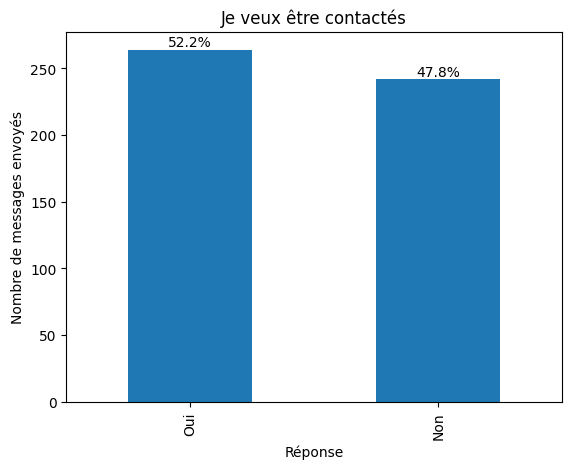

In [ ]:
import matplotlib.pyplot as plt

# Calculate value counts and proportions
value_counts = labels.value_counts()
proportions = labels.value_counts(normalize=True) * 100

# Plot label distribution
ax = value_counts.plot(kind='bar')

# Add proportion % labels on each bar
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2.,
            height + 0.1, # Adjust vertical position
            '{:1.1f}%'.format(proportions.iloc[i]),
            ha='center', va='bottom')

plt.title("Je veux être contactés")
plt.xlabel("Réponse")
plt.ylabel("Nombre de messages envoyés")
plt.show()

In [ ]:
# Export dataset
dataset = pd.concat([features, labels], axis=1)
dataset.to_csv(DATA_PATH + '2026-03-24 whatsapp dataset.csv', index=False)
dataset

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,updated_at,apprenant.sexe,mission_locale,deja_connu,label
0,-7259,-1078,0,-991,-1033,60,-670,-494,M,DE LA MAYENNE,0.0,Non
1,-6378,-686,0,-652,-680,49,-304,-134,F,DU HAUT BOCAGE,0.0,Non
2,-9286,-732,0,-669,-661,60,-308,-100,M,DE L'AGGLOMERATION D'ELBEUF,0.0,Non
3,-7619,-701,0,-659,-666,60,-310,-131,M,DE L'AGGLOMERATION MANCELLE,0.0,Oui
4,-7969,-381,0,-339,-1033,-334,0,-158,M,DU DROUAIS,0.0,Non
...,...,...,...,...,...,...,...,...,...,...,...,...
501,-7262,-661,0,-661,-730,26,-598,-465,M,94-ML BOISSY ST LEGER,0.0,Oui
502,-6565,-319,0,-319,-323,35,-137,-128,M,DU COUDON AU GAPEAU,0.0,Oui
503,-6920,-662,0,-662,-662,52,-172,-109,M,DES PORTES DE LA BRIE,1.0,Oui
504,-8819,-287,0,-287,-287,77,-182,-88,F,94-ML BOISSY ST LEGER,0.0,Non


# Visualization

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + '2026-03-24 whatsapp dataset.csv')
labels = dataset['label']
# features = dataset.drop(['label', 'apprenant.sexe', 'mission_locale'], axis=1)
features = dataset.drop('label', axis=1)

In [ ]:
# Transform categorical features
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
features = pd.get_dummies(features, columns=['apprenant.sexe', 'mission_locale', 'deja_connu'])
features

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,updated_at,apprenant.sexe_F,apprenant.sexe_M,...,mission_locale_SUD DE LA REUNION,mission_locale_SUD GIRONDE,mission_locale_TECHNOWEST,mission_locale_TULLE CENTRE CORREZE,mission_locale_VALLEE DE MONTMORENCY,mission_locale_VALLEE SUD EMPLOI,mission_locale_VENDEE ATLANTIQUE,mission_locale_VERNON SEINE VEXIN,deja_connu_0.0,deja_connu_1.0
0,-7259,-1078,0,-991,-1033,60,-670,-494,False,True,...,False,False,False,False,False,False,False,False,True,False
1,-6378,-686,0,-652,-680,49,-304,-134,True,False,...,False,False,False,False,False,False,False,False,True,False
2,-9286,-732,0,-669,-661,60,-308,-100,False,True,...,False,False,False,False,False,False,False,False,True,False
3,-7619,-701,0,-659,-666,60,-310,-131,False,True,...,False,False,False,False,False,False,False,False,True,False
4,-7969,-381,0,-339,-1033,-334,0,-158,False,True,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,-7262,-661,0,-661,-730,26,-598,-465,False,True,...,False,False,False,False,False,False,False,False,True,False
502,-6565,-319,0,-319,-323,35,-137,-128,False,True,...,False,False,False,False,False,False,False,False,True,False
503,-6920,-662,0,-662,-662,52,-172,-109,False,True,...,False,False,False,False,False,False,False,False,False,True
504,-8819,-287,0,-287,-287,77,-182,-88,True,False,...,False,False,False,False,False,False,False,False,True,False


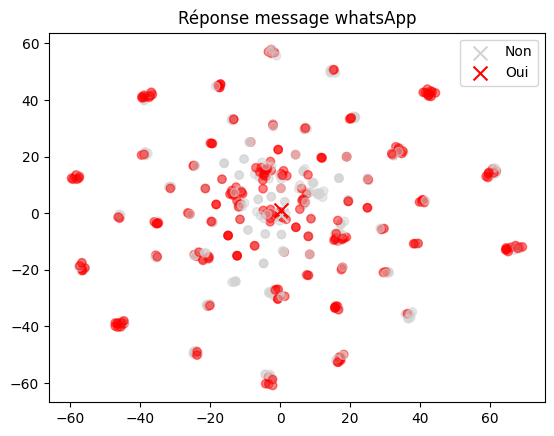

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_std = sc.fit_transform(features)

# Create a t-SNE model and transform the data
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='random', learning_rate=200)
vis_dims = tsne.fit_transform(X_std)
vis_dims.shape

# Plot embeddings
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

colors_list = {
    "Non":"lightgray",
    "Oui":"red"
}

x = [x for x,y in vis_dims]
y = [y for x,y in vis_dims]

colors = [colors_list[label] for label in labels]

plt.scatter(x, y, c=colors, alpha=0.5)
for label in labels.unique():
    avg_x = np.array(x)[labels==label].mean()
    avg_y = np.array(y)[labels==label].mean()
    color = colors_list[label]
    plt.scatter(avg_x, avg_y, marker='x', color=color, s=100, label=label, alpha=1)

plt.title("Réponse message whatsApp")
plt.legend()
plt.show()

In [ ]:
%%capture
!pip install pacmap

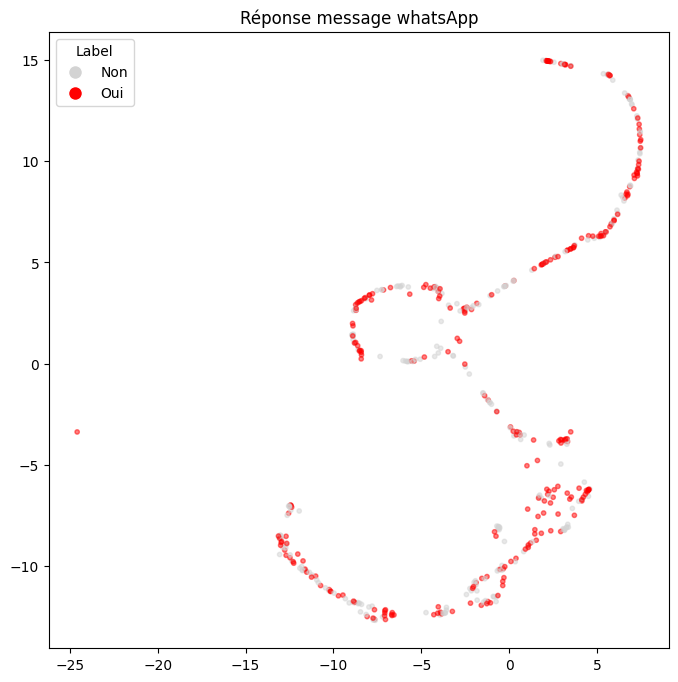

In [ ]:
# PaCMAP dimension reduction
import pacmap
import numpy as np
import matplotlib.pyplot as plt

# Get unique labels
unique_labels = sorted(list(set(labels)))

# Create a color map for unique labels
colors_list = {
    'Non':"lightgray",
    'Oui':"red"
}

# Map labels to colors
mapped_colors = [colors_list[label] for label in labels]

# initializing the pacmap instance
# Setting n_neighbors to "None" leads to an automatic choice shown below in "parameter" section
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(features, init="pca")

# visualize the embedding
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(X_transformed[:, 0], X_transformed[:, 1], c=mapped_colors, s=10, alpha=0.5)

# Create a legend
plt.title("Réponse message whatsApp")

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                              markerfacecolor=colors_list[label], markersize=10)
                   for label in unique_labels]
ax.legend(handles=legend_elements, title="Label")

plt.show()

# Features selection

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + '2026-03-24 whatsapp dataset.csv')
labels = dataset['label']
features = dataset.drop(['label', 'apprenant.sexe', 'mission_locale'], axis=1)
features

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,updated_at,deja_connu
0,-7259,-1078,0,-991,-1033,60,-670,-494,0.0
1,-6378,-686,0,-652,-680,49,-304,-134,0.0
2,-9286,-732,0,-669,-661,60,-308,-100,0.0
3,-7619,-701,0,-659,-666,60,-310,-131,0.0
4,-7969,-381,0,-339,-1033,-334,0,-158,0.0
...,...,...,...,...,...,...,...,...,...
501,-7262,-661,0,-661,-730,26,-598,-465,0.0
502,-6565,-319,0,-319,-323,35,-137,-128,0.0
503,-6920,-662,0,-662,-662,52,-172,-109,1.0
504,-8819,-287,0,-287,-287,77,-182,-88,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

X = features
y = labels

sc = StandardScaler()
X_std = sc.fit_transform(X)

# Importance des features avec une forêt aléatoire
model = RandomForestClassifier()
model.fit(X_std, y)
importance = pd.DataFrame({"feature": X.columns, "importance": model.feature_importances_})
importance = importance.sort_values("importance", ascending=False)

# Sélection des meilleures features avec ANOVA
selector = SelectKBest(score_func=f_classif, k=len(importance))
selector.fit(X_std, y)
best_features = X.columns[selector.get_support()]
best_features

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [2] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Index(['apprenant.date_de_naissance', 'formation.date_inscription',
       'formation.date_fin', 'formation.date_entree', 'contrat.date_debut',
       'contrat.date_fin', 'contrat.date_rupture', 'updated_at', 'deja_connu'],
      dtype='object')

In [ ]:
importance

,feature,importance
4,contrat.date_debut,0.180768
6,contrat.date_rupture,0.160695
0,apprenant.date_de_naissance,0.159914
7,updated_at,0.143647
3,formation.date_entree,0.121951
1,formation.date_inscription,0.113408
5,contrat.date_fin,0.091700
8,deja_connu,0.027917
2,formation.date_fin,0.000000


In [ ]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_std)
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

         Non       1.00      1.00      1.00       242
         Oui       1.00      1.00      1.00       264

    accuracy                           1.00       506
   macro avg       1.00      1.00      1.00       506
weighted avg       1.00      1.00      1.00       506



# Model training

## Pipeline

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + '2026-03-24 whatsapp dataset.csv')
labels = dataset['label']
features = dataset.drop('label', axis=1)
#features = dataset.drop(['label', 'apprenant.sexe', 'mission_locale', 'deja_connu'], axis=1)
features = features.drop(['mission_locale', 'deja_connu'], axis=1)

print(f"Loaded features:{features.shape}")
print(features.columns)

Loaded features:(506, 9)
Index(['apprenant.date_de_naissance', 'formation.date_inscription',
       'formation.date_fin', 'formation.date_entree', 'contrat.date_debut',
       'contrat.date_fin', 'contrat.date_rupture', 'updated_at',
       'apprenant.sexe'],
      dtype='object')


In [ ]:
features.sample(3)

,apprenant.date_de_naissance,formation.date_inscription,formation.date_fin,formation.date_entree,contrat.date_debut,contrat.date_fin,contrat.date_rupture,updated_at,apprenant.sexe
1,-6378,-686,0,-652,-680,49,-304,-134,F
184,-7513,-667,0,-667,-667,61,-548,-497,F
220,-9397,-366,0,-366,-356,0,-307,-201,F


In [ ]:
# Prepare train/test dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from tqdm import tqdm
tqdm.pandas()

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42, shuffle=True, stratify=labels)

# Create training pipeline
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Define the balancing step
smote = SMOTE(random_state=42, sampling_strategy='minority')

# Identify numeric and categorical features
# Ensure X_train is a DataFrame, even if it's currently a Series
numeric_features = [col for col in X_train.columns if 'date' in col]
categorical_features = [col for col in X_train.columns if col not in numeric_features]
print(f"Numeric features: {numeric_features}")
print(f"Categorical features: {categorical_features}")

# Pipeline configuration
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    # ('pca', PCA(n_components=0.99))  # Retain 99% of variance
    ])

# Categorical pipeline: impute and encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    verbose_feature_names_out=False)

# Training pipeline with balancing
def train_model(model, X_train, y_train, X_test, y_test):
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', smote),
        ('model', model)
        ])

    # Train and evaluate balanced KNN
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    print(f"{model.__class__.__name__} Classification Report:")
    print(classification_report(y_test, y_pred))
    return pipeline

# Cross validation score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
def cross_validation(pipeline, X, y):
    # Define a custom scorer for the minority class (assuming class 1 is minority)
    def f1_minority(y_true, y_pred):
        return f1_score(y_true, y_pred, pos_label='Oui')
    f1_scorer = make_scorer(f1_minority)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="f1_weighted")
    print(f"{pipeline.named_steps.model.__class__.__name__} CV: f1-score=%0.4f | std=%0.4f" % (scores.mean(), scores.std()))

# Confusion matrix plot
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(X_test, y_test, pipeline, threshold=0.5):
    # Predict on test
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    y_test = y_test.map({'Non': 0, 'Oui': 1})

    # Apply threshold
    y_pred = (y_probs >= threshold).astype(int)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Normalize by row (true class proportion)
    # cm_normalized = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]*100
    # Normalize by column (true class proportion)
    cm_normalized = cm.astype('float') / cm.sum(axis=0)*100

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=['Non', 'Oui']
    )
    disp.plot(include_values=False, cmap='Blues', ax=ax, colorbar=False)

    # Add percentage labels
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            color = 'white' if cm_normalized[i, j] > 50 else 'black'
            ax.text(j, i, f"{cm_normalized[i, j]:.0f}%\n({cm[i,j]})", ha='center', va='center', color=color)
    ax.set_title(f"{pipeline.named_steps.model.__class__.__name__} (threshold={threshold})")
    plt.show()

# Feature importance
def feature_importance(pipeline):
    # Get feature names after preprocessing
    feature_names_after_preprocessing = pipeline.named_steps['preprocessor'].get_feature_names_out()

    # Get importance based on model type
    model = pipeline['model']
    if isinstance(model, RandomForestClassifier) or hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        title_suffix = "(feature importances)"
    elif hasattr(model, 'coef_'):
        # For binary classification, coef_ is usually 2D, take the first row
        importance = model.coef_[0]
        title_suffix = "(coefficients)"
    else:
        print("Model type does not support feature importance extraction.")
        return

    # Create a DataFrame for visualization
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names_after_preprocessing,
        'Importance': importance
    }).sort_values('Importance', key=abs, ascending=True)

    plt.figure(figsize=(6, 6))
    nb_feat = min(20, len(importance))
    plt.barh(feature_importance_df[-nb_feat:]['Feature'], feature_importance_df[-nb_feat:]['Importance'])
    plt.title(f"Je veux être contacté - {model.__class__.__name__} {title_suffix} (best {nb_feat} features)")
    plt.xlabel("Importance Value")
    plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_threshold_curve(X_test, y_test, pipeline):
    # Predict on test
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    y_test = y_test.map({'Non': 0, 'Oui': 1})

    # Définir une gamme de seuils
    thresholds = np.linspace(0.1, 0.9, 100)
    td_values = []
    fd_values = []

    for threshold in thresholds:
        # Apply threshold
        y_pred = (y_probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        td = 0 if tp+fp == 0 else tp / (tp + fp)
        td_values.append(td)
        fd = 0 if tn+fn == 0 else tn / (tn + fn)
        fd_values.append(fd)

    # Tracer le graphique
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, td_values, label='Taux de détection "oui"', color="blue")
    plt.plot(thresholds, fd_values, label='Taux de détection "non"', color="Red")
    plt.xlabel('Seuil de probabilité')
    plt.ylabel('Taux de détection')
    plt.title('Taux de détection des contacts utiles')
    plt.grid(True)
    plt.legend()
    plt.show()

preprocessor

Numeric features: ['apprenant.date_de_naissance', 'formation.date_inscription', 'formation.date_fin', 'formation.date_entree', 'contrat.date_debut', 'contrat.date_fin', 'contrat.date_rupture', 'updated_at']
Categorical features: ['apprenant.sexe']


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['apprenant.date_de_naissance',
                                  'formation.date_inscription',
                                  'formation.date_fin', 'formation.date_entree',
                                  'contrat.date_debut', 'contrat.date_fin',
                                  'contrat.date_rupture', 'updated_at']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['apprenant.sexe'])],
                  verbose_feature_names_out=False)

## Dummy (48%)

DummyClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.46      0.45      0.45        49
         Oui       0.50      0.51      0.50        53

    accuracy                           0.48       102
   macro avg       0.48      0.48      0.48       102
weighted avg       0.48      0.48      0.48       102

DummyClassifier CV: f1-score=0.4977 | std=0.0131


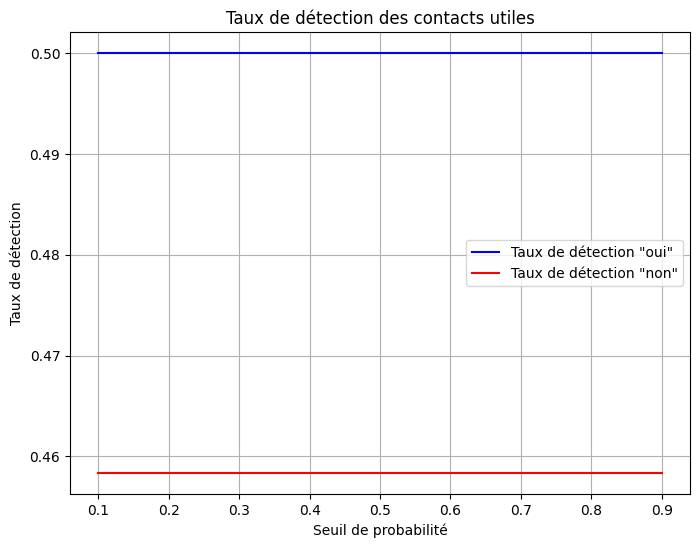

In [ ]:
# Dummy classifier
from sklearn.dummy import DummyClassifier
pipeline = train_model(DummyClassifier(strategy='stratified', random_state=42), X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

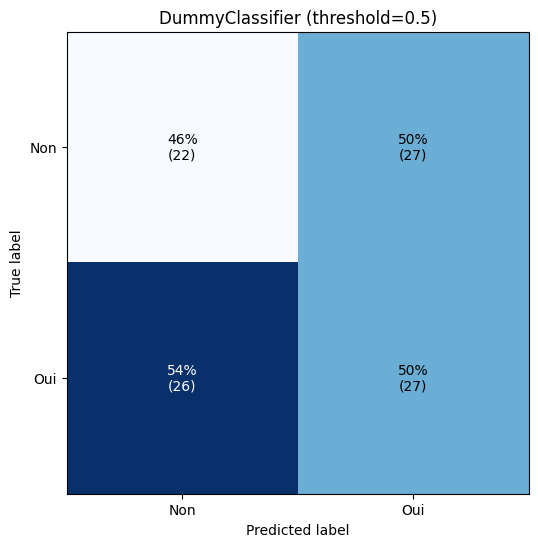

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline)

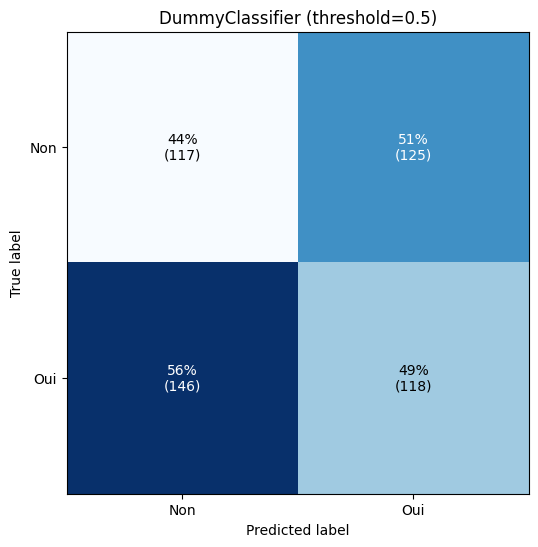

In [ ]:
plot_confusion_matrix(features, labels, pipeline)

## KNN (61%)

KNeighborsClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.60      0.57      0.58        49
         Oui       0.62      0.64      0.63        53

    accuracy                           0.61       102
   macro avg       0.61      0.61      0.61       102
weighted avg       0.61      0.61      0.61       102

KNeighborsClassifier CV: f1-score=0.5344 | std=0.0443


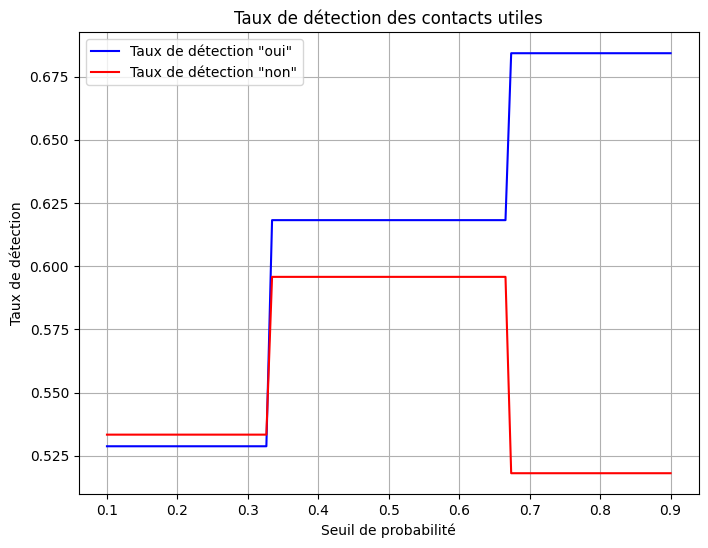

In [ ]:
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier
pipeline = train_model(KNeighborsClassifier(n_neighbors=3), X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

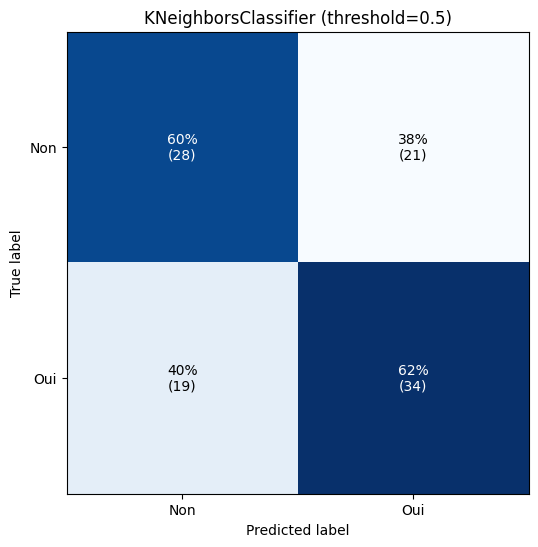

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline)

## Logistic regression (74%/76%)

LogisticRegression Classification Report:
              precision    recall  f1-score   support

         Non       0.61      0.63      0.62        49
         Oui       0.65      0.62      0.63        53

    accuracy                           0.63       102
   macro avg       0.63      0.63      0.63       102
weighted avg       0.63      0.63      0.63       102

LogisticRegression CV: f1-score=0.5619 | std=0.0616


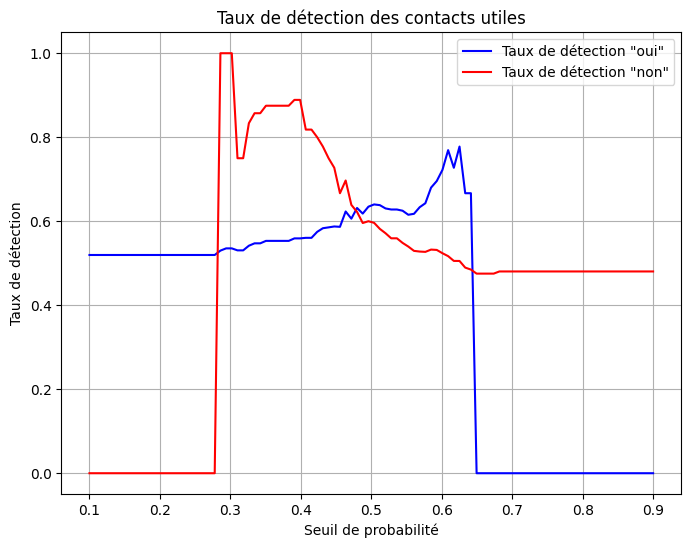

In [ ]:
# Logistic Regression classifier
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=42, max_iter=1000, penalty='l2', solver='liblinear')
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

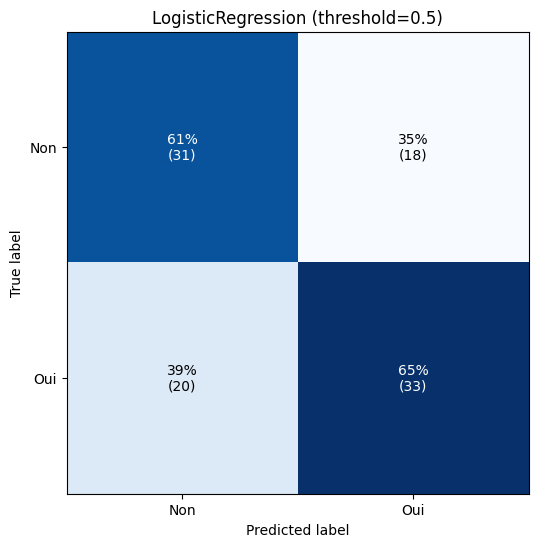

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.5)

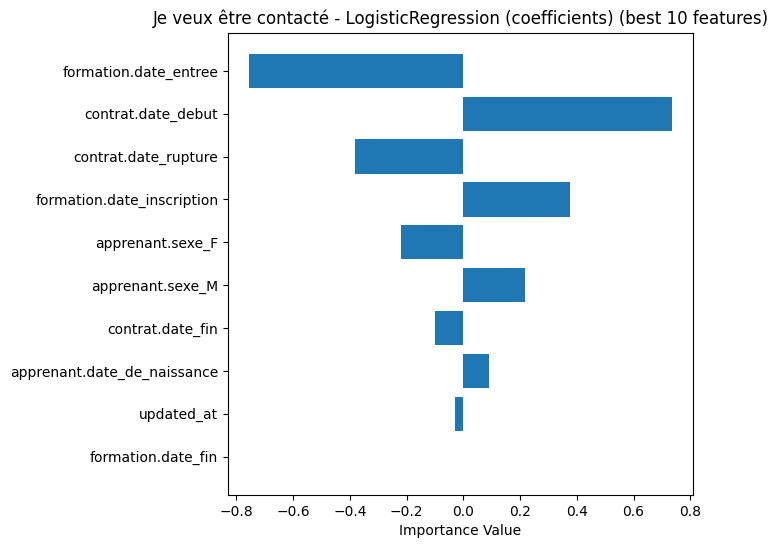

In [ ]:
feature_importance(pipeline)

## SVC (68%)

SVC Classification Report:
              precision    recall  f1-score   support

         Non       0.71      0.59      0.64        49
         Oui       0.67      0.77      0.72        53

    accuracy                           0.69       102
   macro avg       0.69      0.68      0.68       102
weighted avg       0.69      0.69      0.68       102

SVC CV: f1-score=0.5999 | std=0.0375


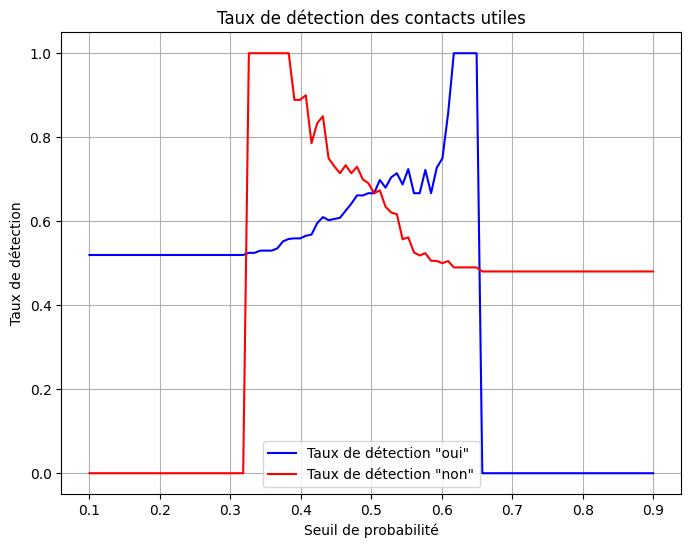

In [ ]:
# Support Vector classifier
from sklearn.svm import SVC
model = SVC(random_state=42, probability=True, kernel='rbf')
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

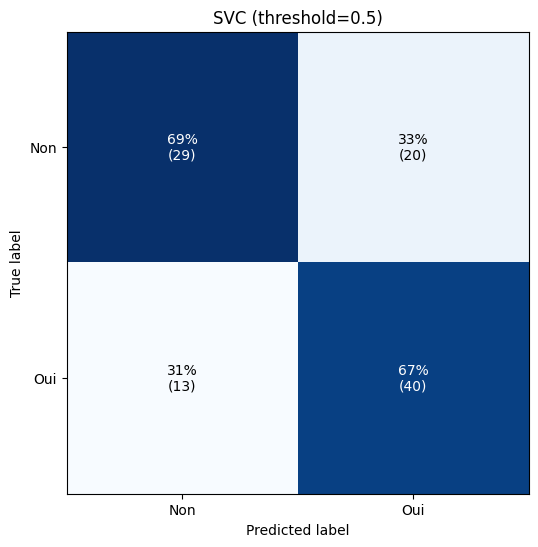

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.5)

## Random Forest (73%)

RandomForestClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.72      0.69      0.71        49
         Oui       0.73      0.75      0.74        53

    accuracy                           0.73       102
   macro avg       0.73      0.72      0.72       102
weighted avg       0.73      0.73      0.73       102

RandomForestClassifier CV: f1-score=0.5893 | std=0.0306


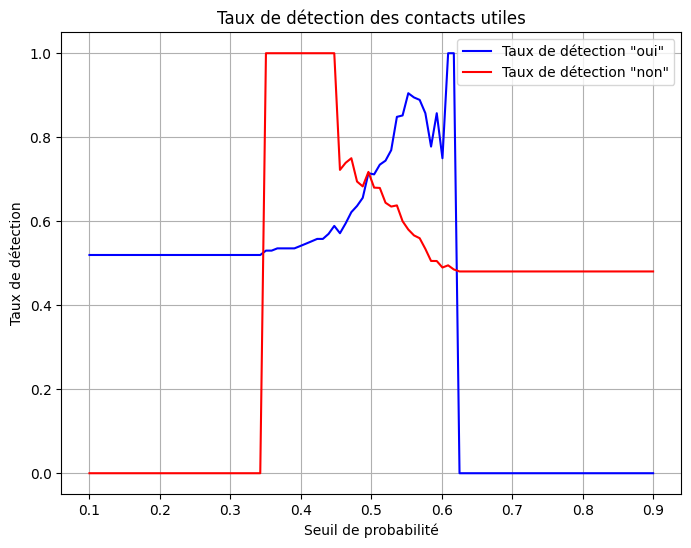

In [ ]:
# Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight='balanced', random_state=42,
                               min_samples_split=20, min_samples_leaf=2,
                               max_depth=5, max_features='sqrt',
                               n_estimators=200)
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

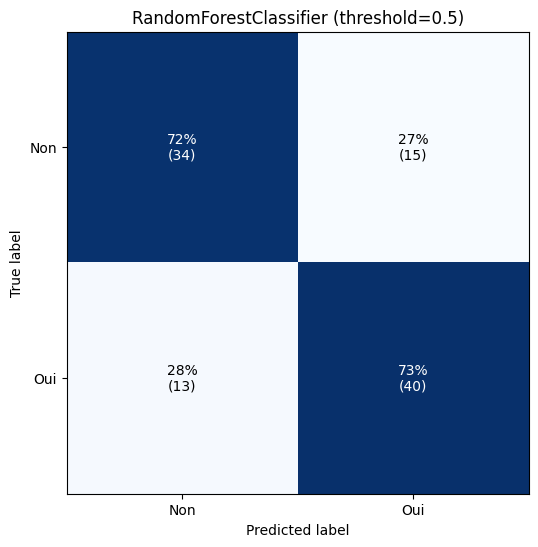

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.5)

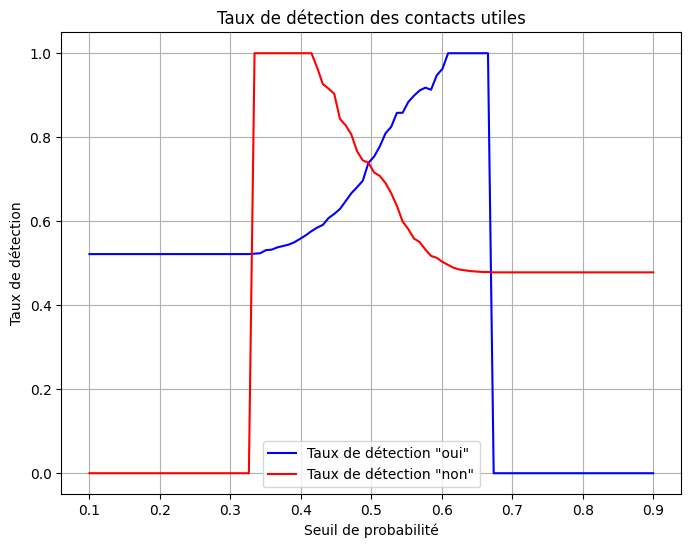

In [ ]:
plot_threshold_curve(features, labels, pipeline)

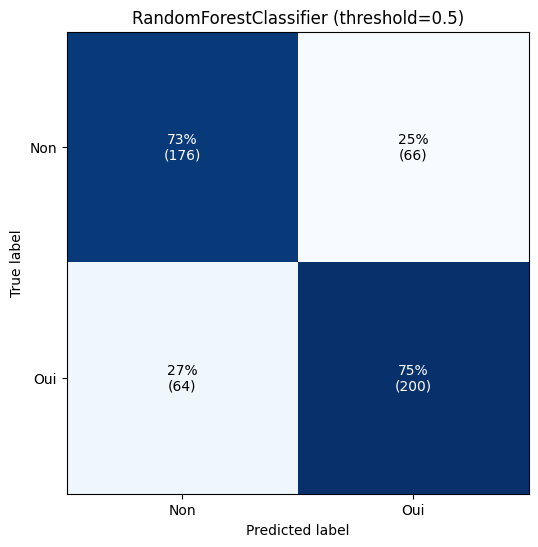

In [ ]:
plot_confusion_matrix(features, labels, pipeline, 0.5)

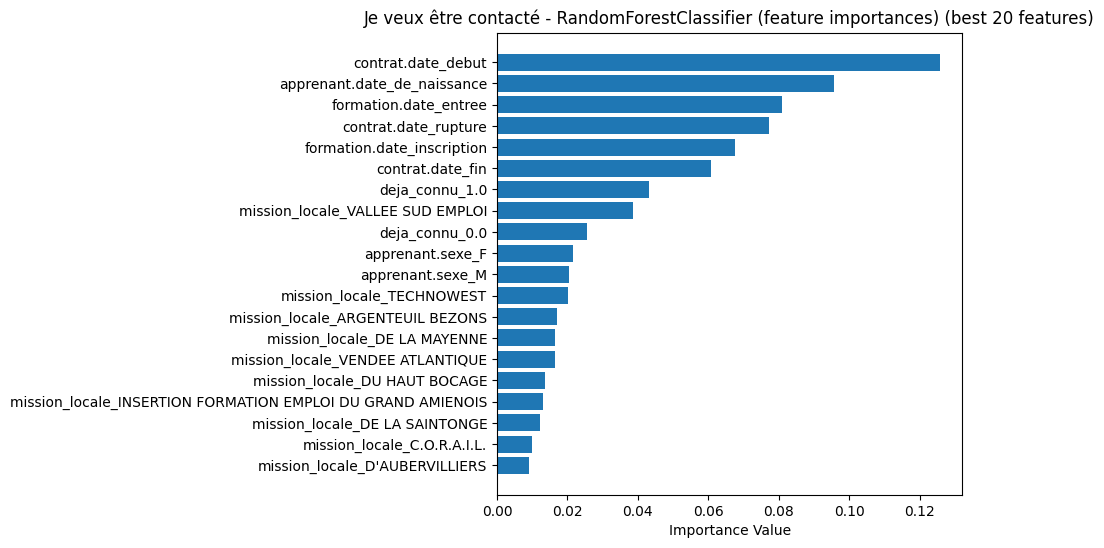

In [ ]:
feature_importance(pipeline)

In [ ]:
print(f"Number of estimators: {len(pipeline.named_steps['model'].estimators_)}")

Number of estimators: 200


In [ ]:
from sklearn.tree import export_text

# Extraire le premier arbre de la forêt
tree = pipeline.named_steps['model'].estimators_[0]
feature_names_after_preprocessing = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Afficher les règles sous forme de texte
tree_rules = export_text(tree, feature_names=feature_names_after_preprocessing)
print(tree_rules)

|--- deja_connu_1.0 <= 0.39
|   |--- apprenant.sexe_M <= 0.50
|   |   |--- class: 0.0
|   |--- apprenant.sexe_M >  0.50
|   |   |--- mission_locale_ET DE LA FORMATION DU THOUARSAIS <= 0.41
|   |   |   |--- mission_locale_LA ROCHELLE - RE - PAYS D'AUNIS <= 0.50
|   |   |   |   |--- contrat.date_debut <= -0.58
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- contrat.date_debut >  -0.58
|   |   |   |   |   |--- class: 1.0
|   |   |   |--- mission_locale_LA ROCHELLE - RE - PAYS D'AUNIS >  0.50
|   |   |   |   |--- class: 0.0
|   |   |--- mission_locale_ET DE LA FORMATION DU THOUARSAIS >  0.41
|   |   |   |--- class: 0.0
|--- deja_connu_1.0 >  0.39
|   |--- contrat.date_fin <= 0.40
|   |   |--- deja_connu_0.0 <= 0.09
|   |   |   |--- mission_locale_SUD DE LA REUNION <= 0.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- mission_locale_SUD DE LA REUNION >  0.50
|   |   |   |   |--- class: 1.0
|   |   |--- deja_connu_0.0 >  0.09
|   |   |   |--- class: 0.0
|   |--- contrat.date_fin 

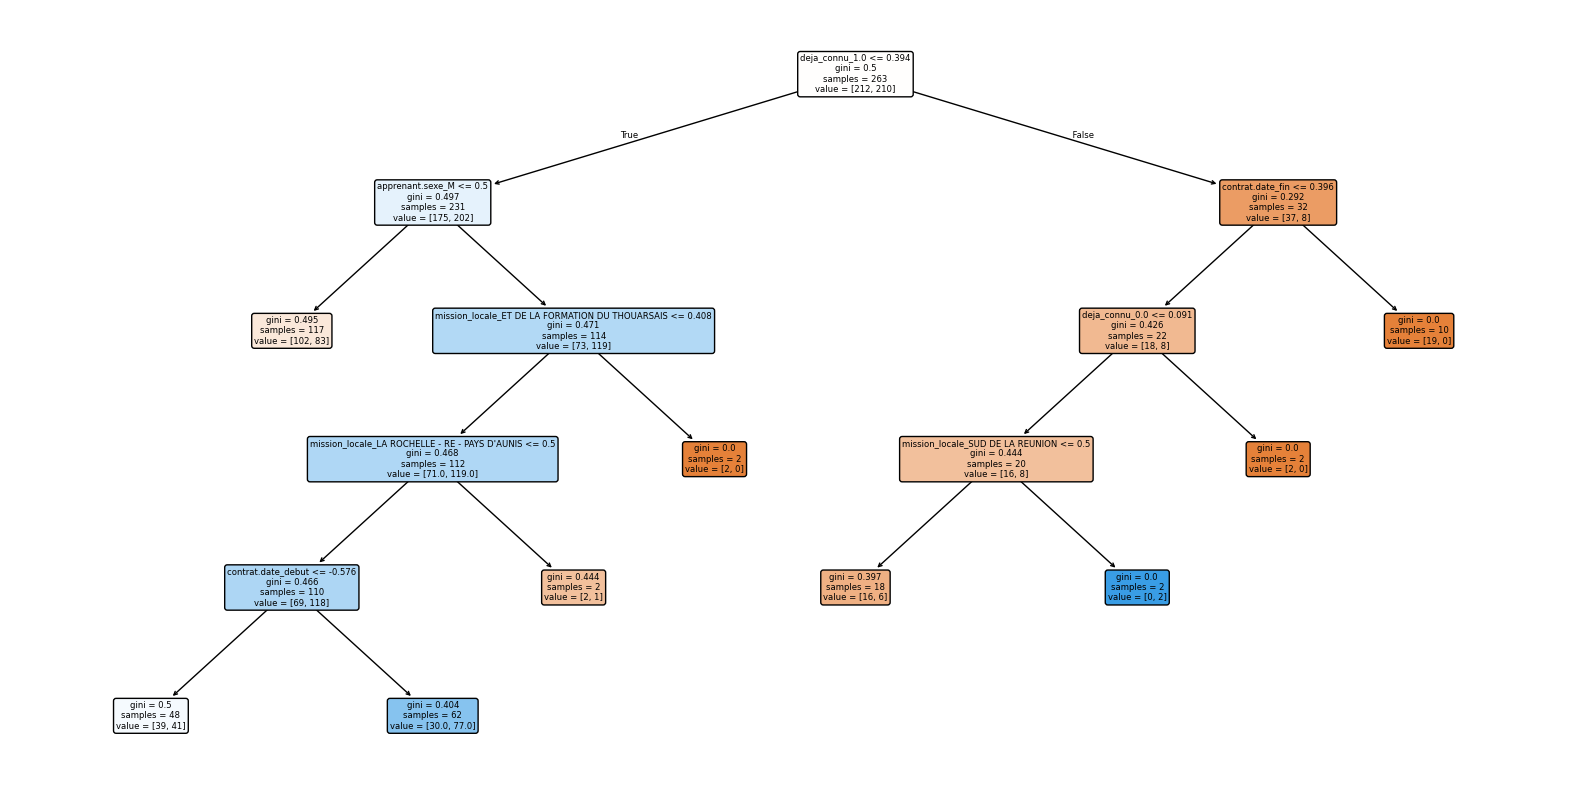

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=feature_names_after_preprocessing, filled=True, rounded=True)
plt.show()

## SGD (64%)

SGDClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.77      0.41      0.53        49
         Oui       0.62      0.89      0.73        53

    accuracy                           0.66       102
   macro avg       0.69      0.65      0.63       102
weighted avg       0.69      0.66      0.63       102

SGDClassifier CV: f1-score=0.6007 | std=0.0331


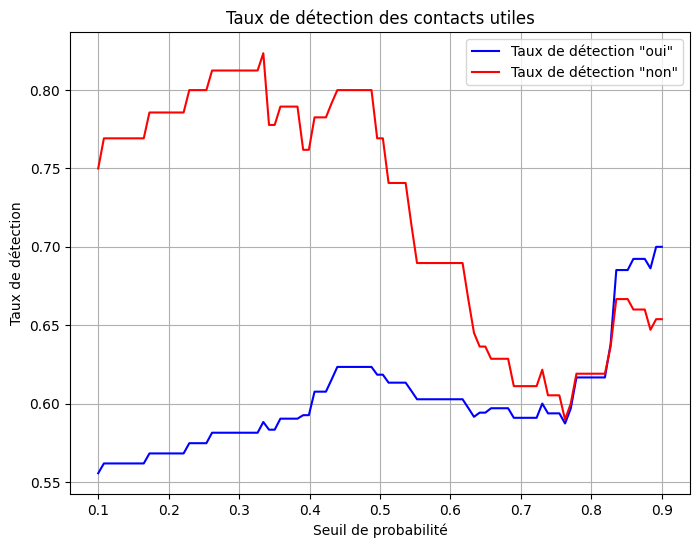

In [ ]:
from sklearn.linear_model import SGDClassifier
model = SGDClassifier(class_weight='balanced', loss='log_loss')
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

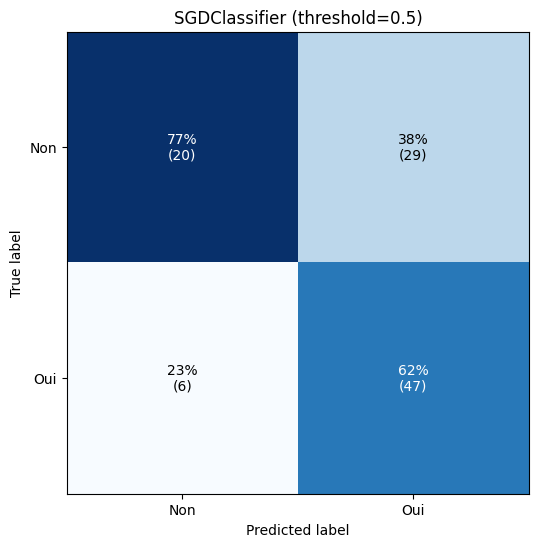

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.5)

## Bagging SGD (75%)

BaggingClassifier Classification Report:
              precision    recall  f1-score   support

         Non       0.73      0.67      0.70        49
         Oui       0.72      0.77      0.75        53

    accuracy                           0.73       102
   macro avg       0.73      0.72      0.72       102
weighted avg       0.73      0.73      0.72       102

BaggingClassifier CV: f1-score=0.6291 | std=0.0503


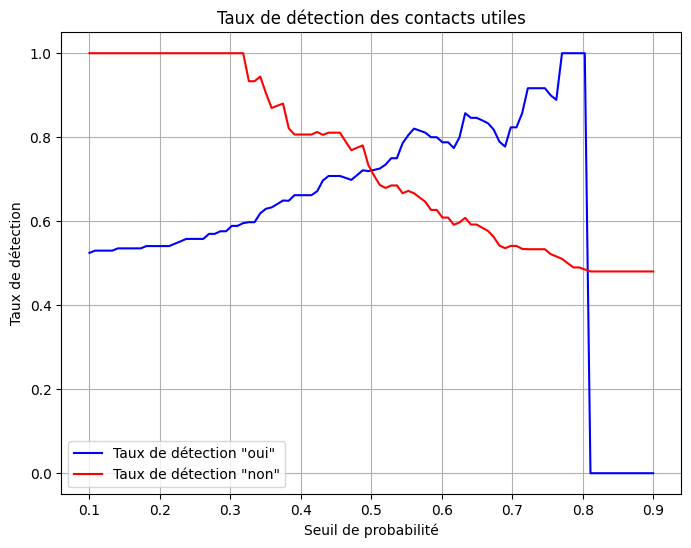

In [ ]:
# Bagging SGD
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import SGDClassifier

# Sparse-aware bagging
base_estimator = SGDClassifier(class_weight='balanced', loss='log_loss', random_state=42, n_jobs=-1)
model = BaggingClassifier(
            estimator=base_estimator, # Changed base_estimator to estimator
            n_estimators=200,
            max_samples=0.2,  # Use 20% of samples per estimator
            n_jobs=-1,
            verbose=0
        )
pipeline = train_model(model, X_train, y_train, X_test, y_test)
cross_validation(pipeline, features, labels)
plot_threshold_curve(X_test, y_test, pipeline)

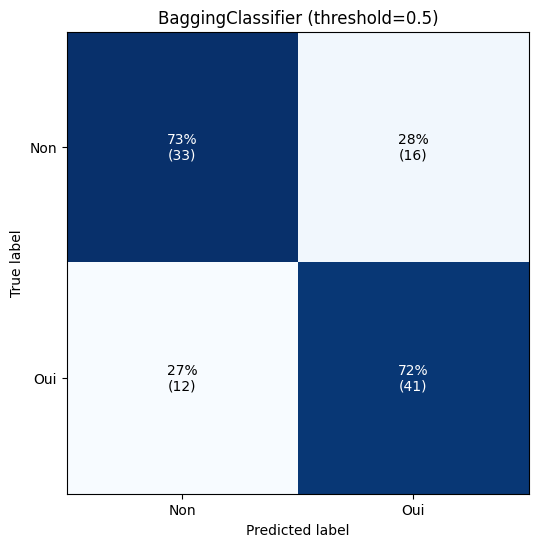

In [ ]:
plot_confusion_matrix(X_test, y_test, pipeline, 0.5)

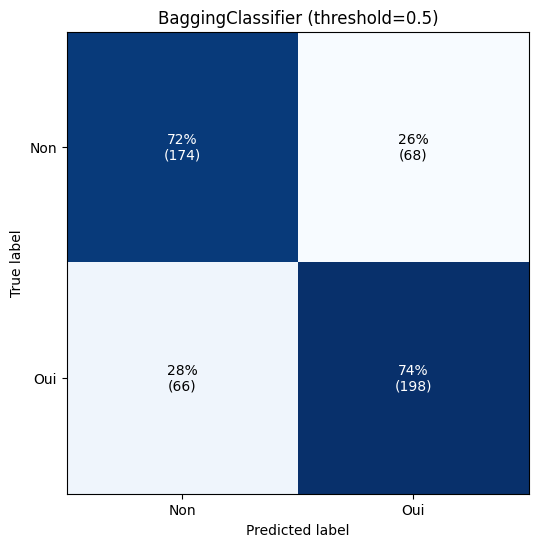

In [ ]:
plot_confusion_matrix(features, labels, pipeline, 0.5)

In [ ]:
# Get features importance
import numpy as np

# Get coefficients from each estimator
coefs = np.array([est.coef_[0] for est in pipeline['model'].estimators_])

# Average absolute coefficients
feature_importance = np.mean(np.abs(coefs), axis=0)

# Sort features by importance
sorted_idx = np.argsort(feature_importance)[::-1]

# Print feature ranking
for idx in sorted_idx:
    print(f"Feature {idx}: {feature_importance[idx]:.4f}")

Feature 115: 4.0740
Feature 21: 3.5703
Feature 28: 3.4980
Feature 14: 3.2571
Feature 26: 3.1978
Feature 56: 3.1956
Feature 4: 3.1344
Feature 78: 3.0905
Feature 112: 3.0134
Feature 114: 2.9940
Feature 79: 2.9448
Feature 76: 2.8766
Feature 40: 2.7432
Feature 110: 2.6947
Feature 17: 2.6895
Feature 90: 2.6420
Feature 12: 2.6325
Feature 6: 2.6289
Feature 77: 2.5564
Feature 15: 2.5560
Feature 107: 2.5228
Feature 91: 2.5061
Feature 53: 2.4993
Feature 33: 2.4934
Feature 94: 2.4889
Feature 16: 2.4780
Feature 81: 2.4166
Feature 59: 2.3924
Feature 3: 2.3666
Feature 7: 2.3512
Feature 89: 2.3127
Feature 104: 2.2690
Feature 96: 2.2637
Feature 42: 2.2433
Feature 72: 2.2247
Feature 70: 2.1629
Feature 106: 2.1210
Feature 118: 2.0711
Feature 97: 2.0666
Feature 18: 2.0205
Feature 61: 1.9941
Feature 32: 1.9732
Feature 117: 1.9352
Feature 86: 1.8940
Feature 13: 1.8651
Feature 46: 1.8546
Feature 67: 1.8520
Feature 19: 1.8482
Feature 54: 1.8324
Feature 119: 1.8073
Feature 39: 1.7515
Feature 31: 1.7089
Featur

# Upload model

In [ ]:
# Save dataset to HF
import pandas as pd
from datasets import Dataset
EXPORT_DATE = "2026-03-26"
VERSION = f"whatsapp-{EXPORT_DATE}"
repo_id = f"tableaudebord-apprentissage/{VERSION}"
hf_dataset = Dataset.from_pandas(dataset)

token = userdata.get('TBA_HF_TOKEN')
hf_dataset.push_to_hub(repo_id, private=True, token=token)
url = f"https://huggingface.co/datasets/{repo_id}"
print(url)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 17.8kB / 17.8kB            

                              : 100%|##########| 17.8kB / 17.8kB            

https://huggingface.co/datasets/tableaudebord-apprentissage/wa-2026-03-26


In [ ]:
# Save model to HF
import joblib
from tempfile import mkdtemp, mkstemp
from pathlib import Path
from huggingface_hub import HfApi

classifier = pipeline
local_repo = mkdtemp(prefix="tmp-")
model_file = "model.joblib"

joblib.dump(classifier, Path(local_repo) / model_file)
api = HfApi()

# Delete previous repo with the same name
try:
    print(f"Deleting existing repo: {repo_id}")
    api.delete_repo(repo_id=repo_id, token=token)
except:
    pass

# Create repo
print(f"Creating repo: {repo_id}")
api.create_repo(repo_id=repo_id, token=token, repo_type="model", private=True)

# Upload model
print(f"Uploading model: {local_repo}")
out = api.upload_folder(
    folder_path=local_repo,
    repo_id=repo_id,
    token=token,
    repo_type="model",
    commit_message=f"pushing model '{EXPORT_DATE}' ML model",
)
url = f"https://huggingface.co/{repo_id}"
print(url)

Deleting existing repo: tableaudebord-apprentissage/wa-2026-03-26
Creating repo: tableaudebord-apprentissage/wa-2026-03-26
Uploading model: /tmp/tmp-sudh9s8r


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...a-bg-wa-2026-03-26.joblib: 100%|##########|  726kB /  726kB            

  ...a-bg-wa-2026-03-26.joblib: 100%|##########|  726kB /  726kB            

https://huggingface.co/tableaudebord-apprentissage/wa-2026-03-26


# Test dataset

In [ ]:
import pandas as pd
wa_datas = pd.read_json(DATA_PATH + '2026-03-24 export_whatsapp.json')
print(f"Loaded wa_datas: {wa_datas.shape}")
wa_datas.sample(3)

Loaded wa_datas: (3194, 29)


,_id,effectif_id,mission_locale_id,created_at,effectif_snapshot,effectif_snapshot_date,brevo,current_status,date_rupture,updated_at,...,probleme_type,a_traiter,injoignable,whatsapp_no_help_responded,whatsapp_no_help_responded_at,whatsapp_callback_requested,whatsapp_callback_requested_at,probleme_detail,organisme_data,deca_feedback
1811,{'$oid': '698337b94fded751775b4e7d'},{'$oid': '695de202878f0aa0f5c607c0'},{'$oid': '67b756f94dc1b65fbd00302b'},{'$date': '2026-02-04T12:12:41.088Z'},"{'_id': {'$oid': '695de202878f0aa0f5c607c0'}, ...",{'$date': '2026-02-04T12:12:41.088Z'},{'token': '19459f92-cd27-45f6-923c-ab40d70e0f8...,"{'value': 'RUPTURANT', 'date': {'$date': '2026...",{'$date': '2026-01-12T00:00:00.000Z'},{'$date': '2026-03-06T09:16:12.993Z'},...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1805,{'$oid': '698337b34fded751775b4e27'},{'$oid': '695510c323f3dac3d08b6154'},{'$oid': '67b756f74dc1b65fbd002fa2'},{'$date': '2026-02-04T12:12:35.194Z'},"{'_id': {'$oid': '695510c323f3dac3d08b6154'}, ...",{'$date': '2026-02-04T12:12:35.194Z'},{'token': 'fd964ff6-30b9-4709-98b7-07a723701eb...,"{'value': 'RUPTURANT', 'date': {'$date': '2025...",{'$date': '2025-12-15T00:00:00.000Z'},{'$date': '2026-02-26T10:41:51.600Z'},...,jeune_injoignable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,{'$oid': '69065740c51db56da1f658ac'},{'$oid': '68adef53569f24bbc2a932d8'},{'$oid': '67b756f94dc1b65fbd003042'},{'$date': '2025-11-01T18:53:51.968Z'},"{'_id': {'$oid': '68adef53569f24bbc2a932d8'}, ...",{'$date': '2026-01-23T16:13:50.070Z'},{'token': 'e877e9c2-84cf-4cb8-9a2e-412ba644255...,"{'value': 'ABANDON', 'date': {'$date': '2026-0...",{'$date': '2025-09-01T00:00:00.000Z'},{'$date': '2026-02-24T13:42:56.646Z'},...,jeune_injoignable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Extract features
test_dataset = wa_datas.copy()
filter = (~wa_datas['whatsapp_callback_requested'].isna()) | (~wa_datas['whatsapp_no_help_responded'].isna())
test_dataset = test_dataset[filter].reset_index(drop=True)
test_dataset['mission_locale'] = test_dataset['mission_locale'].apply(pd.Series)['nom']
effectifs = test_dataset['effectif_snapshot'].apply(pd.Series)
apprenants = effectifs['apprenant'].apply(pd.Series).add_prefix('apprenant.')
contrats = effectifs['contrats'].apply(lambda x: pd.Series(x[0])).add_prefix('contrat.')
formations = effectifs['formation'].apply(pd.Series).add_prefix('formation.')
effectifs = pd.concat([test_dataset, apprenants, formations, contrats], axis=1)
date_cols = ['apprenant.date_de_naissance',
             'formation.date_inscription',
             'formation.date_fin',
             'formation.date_entree',
             'contrat.date_debut',
             'contrat.date_fin',
             'contrat.date_rupture',
]
test_features = effectifs[date_cols].map(lambda x: x['$date'] if isinstance(x, dict) else '') # Extract date string

# Add categorical cols
cat_cols = ['apprenant.sexe', 'mission_locale', 'deja_connu']
test_features[cat_cols] = effectifs[cat_cols]
# features[cat_cols] = features[cat_cols].fillna('').astype(str)
# features['deja_connu'] = features['deja_connu'].replace({'':'0.0'})

test_features.sample(2).to_dict(orient='records')

[{'apprenant.date_de_naissance': '2007-12-20T00:00:00.000Z',
  'formation.date_inscription': '2025-09-01T00:00:00.000Z',
  'formation.date_fin': '2027-07-05T00:00:00.000Z',
  'formation.date_entree': '2025-09-01T00:00:00.000Z',
  'contrat.date_debut': '2025-09-02T00:00:00.000Z',
  'contrat.date_fin': '2027-08-31T00:00:00.000Z',
  'contrat.date_rupture': '2025-12-03T00:00:00.000Z',
  'apprenant.sexe': 'F',
  'mission_locale': 'PLAINE CENTRALE DU VAL DE MARNE - AIFP',
  'deja_connu': 0.0},
 {'apprenant.date_de_naissance': '2006-09-06T00:00:00.000Z',
  'formation.date_inscription': '2024-10-10T00:00:00.000Z',
  'formation.date_fin': '2026-06-30T00:00:00.000Z',
  'formation.date_entree': '2024-10-10T00:00:00.000Z',
  'contrat.date_debut': '2025-01-27T00:00:00.000Z',
  'contrat.date_fin': '2026-06-30T00:00:00.000Z',
  'contrat.date_rupture': '2025-11-01T00:00:00.000Z',
  'apprenant.sexe': 'M',
  'mission_locale': 'INTERCOMMUNALE DE POISSY - CONFLANS STE HONORINE',
  'deja_connu': 0.0}]

In [ ]:
# Prepare date features
date_cols = ['apprenant.date_de_naissance',
             'formation.date_inscription',
             'formation.date_fin',
             'formation.date_entree',
             'contrat.date_debut',
             'contrat.date_fin',
             'contrat.date_rupture',
]
test_features[date_cols] = test_features[date_cols].map(lambda x: pd.to_datetime(str(x), utc=True, errors='coerce')) # Cast as date
test_features[date_cols] = test_features[date_cols].sub(test_features['formation.date_fin'], axis=0) # Diff with end date
test_features[date_cols] = test_features[date_cols].map(lambda x: x.days if isinstance(x, pd.Timedelta) else 0) # Keep days

# Prepare cat features
cat_cols = ['apprenant.sexe', 'mission_locale', 'deja_connu']
test_features[cat_cols] = test_features[cat_cols].fillna('').astype(str)
test_features['deja_connu'] = test_features['deja_connu'].replace({'':'0.0'})

test_features.sample(2).to_dict(orient='records')

[{'apprenant.date_de_naissance': -7285,
  'formation.date_inscription': -590,
  'formation.date_fin': 0,
  'formation.date_entree': -590,
  'contrat.date_debut': -593,
  'contrat.date_fin': 60,
  'contrat.date_rupture': -584,
  'apprenant.sexe': 'F',
  'mission_locale': 'DU LUBERON ET DES MONTS DE VAUCLUSE',
  'deja_connu': '0.0'},
 {'apprenant.date_de_naissance': -7450,
  'formation.date_inscription': -683,
  'formation.date_fin': 0,
  'formation.date_entree': -683,
  'contrat.date_debut': -352,
  'contrat.date_fin': 0,
  'contrat.date_rupture': -337,
  'apprenant.sexe': 'F',
  'mission_locale': 'LILLE AVENIRS',
  'deja_connu': '0.0'}]

# Statistical description

In [ ]:
# Reload dataset
import pandas as pd
dataset = pd.read_csv(DATA_PATH + '2026-02-23 whatsapp dataset.csv')
labels = dataset['label']
features = dataset.drop('label', axis=1)

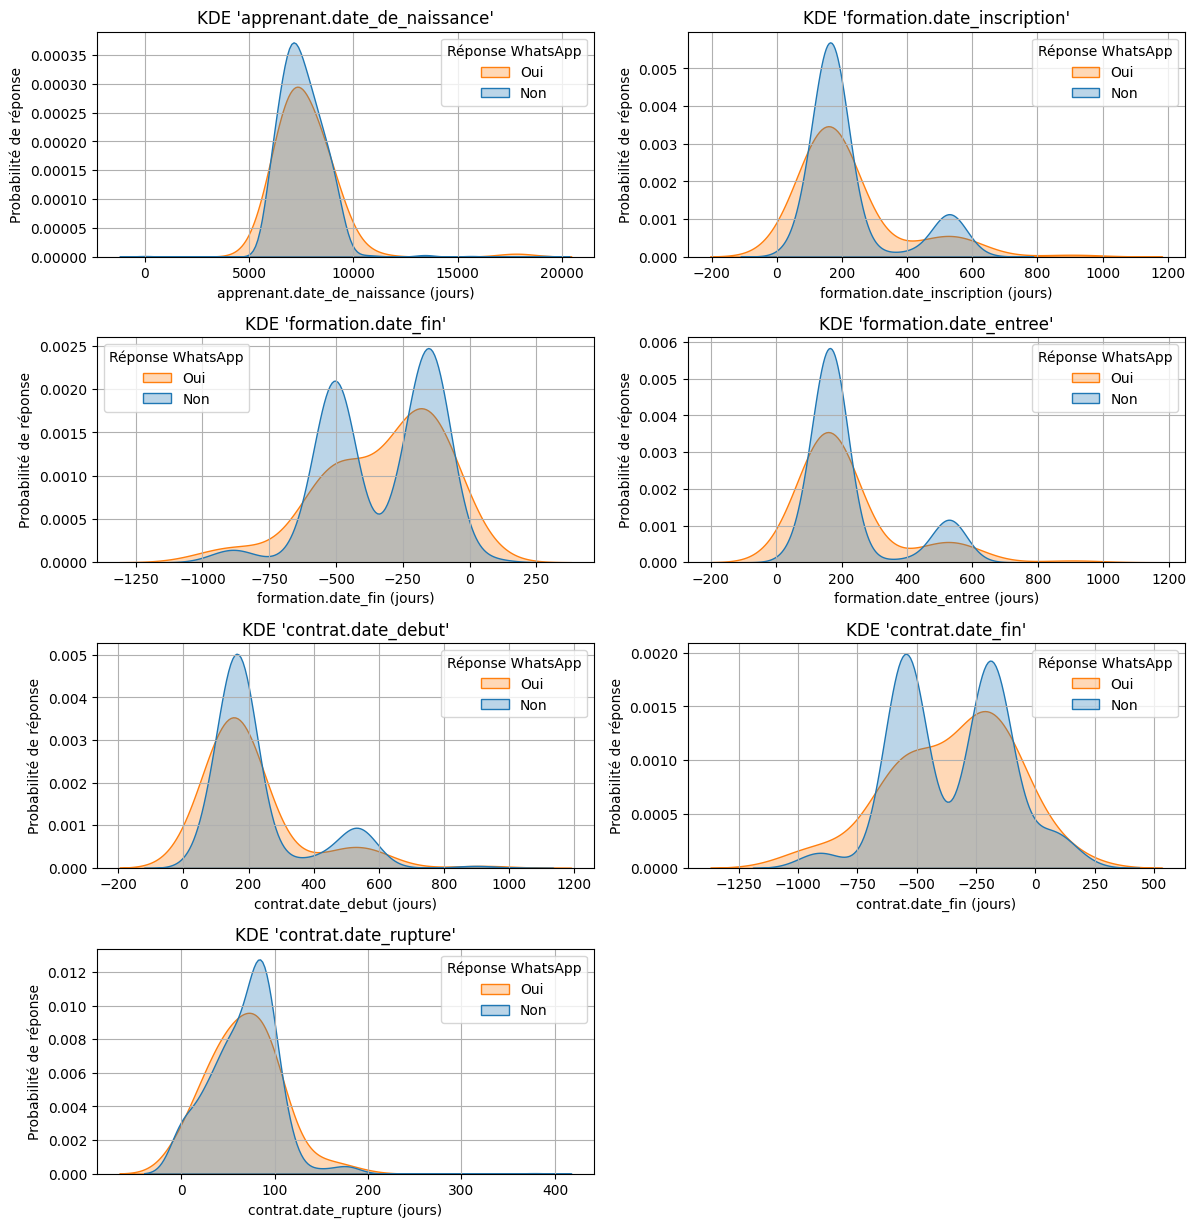

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Determine the number of subplots needed
num_features = len(features.columns)
num_rows = (num_features + 1) // 2  # Arrange in 2 columns
num_cols = 2

plt.figure(figsize=(12, 3 * num_rows))
numeric_features = [col for col in features.columns if 'date' in col]

for i, feat in enumerate(numeric_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.kdeplot(data=dataset, x=feat, hue="label", bw_adjust=1.5, common_norm=False, fill=True, alpha=0.3)
    plt.title(f"KDE '{feat}'")
    plt.xlabel(f"{feat} (jours)")
    plt.ylabel("Probabilité de réponse")
    plt.grid(True)
    plt.legend(title="Réponse WhatsApp", labels=['Oui', 'Non'])

plt.tight_layout()
plt.show()
